In [7]:
install.packages('haven')
install.packages('dplyr')
install.packages("devtools")
devtools::install_github("MathiasHarrer/dmetar")


The downloaded binary packages are in
	/var/folders/st/gm4vk9215ls0bdt0m5nk_pq40000gn/T//Rtmpm8Ey1O/downloaded_packages

The downloaded binary packages are in
	/var/folders/st/gm4vk9215ls0bdt0m5nk_pq40000gn/T//Rtmpm8Ey1O/downloaded_packages

The downloaded binary packages are in
	/var/folders/st/gm4vk9215ls0bdt0m5nk_pq40000gn/T//Rtmpm8Ey1O/downloaded_packages


DEoptimR     (NA    -> 1.0-11   ) [CRAN]
mclust       (NA    -> 6.0.0    ) [CRAN]
modeltools   (NA    -> 0.2-23   ) [CRAN]
colorspace   (NA    -> 2.0-3    ) [CRAN]
mathjaxr     (NA    -> 1.6-0    ) [CRAN]
vctrs        (0.5.0 -> 0.5.1    ) [CRAN]
pkgload      (1.3.1 -> 1.3.2    ) [CRAN]
RcppEigen    (NA    -> 0.3.3.9.3) [CRAN]
nloptr       (NA    -> 2.0.3    ) [CRAN]
minqa        (NA    -> 1.2.5    ) [CRAN]
pbapply      (NA    -> 1.6-0    ) [CRAN]
metadat      (NA    -> 1.2-0    ) [CRAN]
viridisLite  (NA    -> 0.4.1    ) [CRAN]
RColorBrewer (NA    -> 1.1-3    ) [CRAN]
munsell      (NA    -> 0.5.0    ) [CRAN]
labeling     (NA    -> 0.4.2    ) [CRAN]
farver       (NA    -> 2.1.1    ) [CRAN]
scales       (NA    -> 1.2.1    ) [CRAN]
isoband      (NA    -> 0.2.6    ) [CRAN]
gtable       (NA    -> 0.3.1    ) [CRAN]
abind        (NA    -> 1.4-5    ) [CRAN]
CompQuadForm (NA    -> 1.4.3    ) [CRAN]
lme4         (NA    -> 1.1-31   ) [CRAN]
metafor      (NA    -> 3.8-1    ) [CRAN]
kernlab      (NA

Installing 38 packages: DEoptimR, mclust, modeltools, colorspace, mathjaxr, vctrs, pkgload, RcppEigen, nloptr, minqa, pbapply, metadat, viridisLite, RColorBrewer, munsell, labeling, farver, scales, isoband, gtable, abind, CompQuadForm, lme4, metafor, kernlab, robustbase, diptest, prabclus, flexmix, ggplot2, magic, meta, fpc, MuMIn, poibin, ggrepel, netmeta, gridExtra




The downloaded binary packages are in
	/var/folders/st/gm4vk9215ls0bdt0m5nk_pq40000gn/T//Rtmpm8Ey1O/downloaded_packages
* checking for file ‘/private/var/folders/st/gm4vk9215ls0bdt0m5nk_pq40000gn/T/Rtmpm8Ey1O/remotes2993ab54ce4/MathiasHarrer-dmetar-87eca88/DESCRIPTION’ ... OK
* preparing ‘dmetar’:
* checking DESCRIPTION meta-information ... OK
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
* building ‘dmetar_0.0.9000.tar.gz’



In [4]:
# https://bookdown.org/MathiasHarrer/Doing_Meta_Analysis_in_R/discovering-R.html
library(haven); library(dplyr)



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [5]:
data <- read_dta('example1.dta')

In [8]:
data
# a = the number of people with the outcome in the treatment group
# r1 = the total number of people in the treatment group
# c = the number of people with the outcome in the control group
# r2 = the total number of people in the control group

name,year,a,r1,c,r2
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Slama,1990,1,104,1,106
Porter,1972,5,101,4,90
Demers,1990,15,292,5,292
Stewart,1982,11,504,4,187
Page,1986,8,114,5,68
Slama,1995,42,2199,5,929
Haug,1994,20,154,7,109
Russell,1979,34,1031,8,1107
Wilson,1982,21,106,11,105


In [9]:
data$'b' <- data$'r1' - data$'a'
data$'d' <- data$'r2' - data$'c'

In [10]:
data

name,year,a,r1,c,r2,b,d
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Slama,1990,1,104,1,106,103,105
Porter,1972,5,101,4,90,96,86
Demers,1990,15,292,5,292,277,287
Stewart,1982,11,504,4,187,493,183
Page,1986,8,114,5,68,106,63
Slama,1995,42,2199,5,929,2157,924
Haug,1994,20,154,7,109,134,102
Russell,1979,34,1031,8,1107,997,1099
Wilson,1982,21,106,11,105,85,94


In [12]:
??forest.meta

R Information

Help files with alias or concept or title matching ‘forest.meta’ using
regular expression matching:


meta::forest.meta       Forest plot to display the result of a
                        meta-analysis
  Aliases: forest.meta
meta::forest.metabind   Forest plot to display the result of a
                        meta-analysis
  Aliases: forest.metabind


Type '?PKG::FOO' to inspect entries 'PKG::FOO', or 'TYPE?PKG::FOO' for
entries like 'PKG::FOO-TYPE'.




In [13]:
library(meta)

Loading 'meta' package (version 6.0-0).
Type 'help(meta)' for a brief overview.
Readers of 'Meta-Analysis with R (Use R!)' should install
older version of 'meta' package: https://tinyurl.com/dt4y5drs



In [25]:
m.publ = metabin(data$'a', 
                 data$'r1',
                 data$'c',
                 data$'r2',
                 sm="OR" #, label.left = paste(data$'name', ', ', data$'year')
                        )

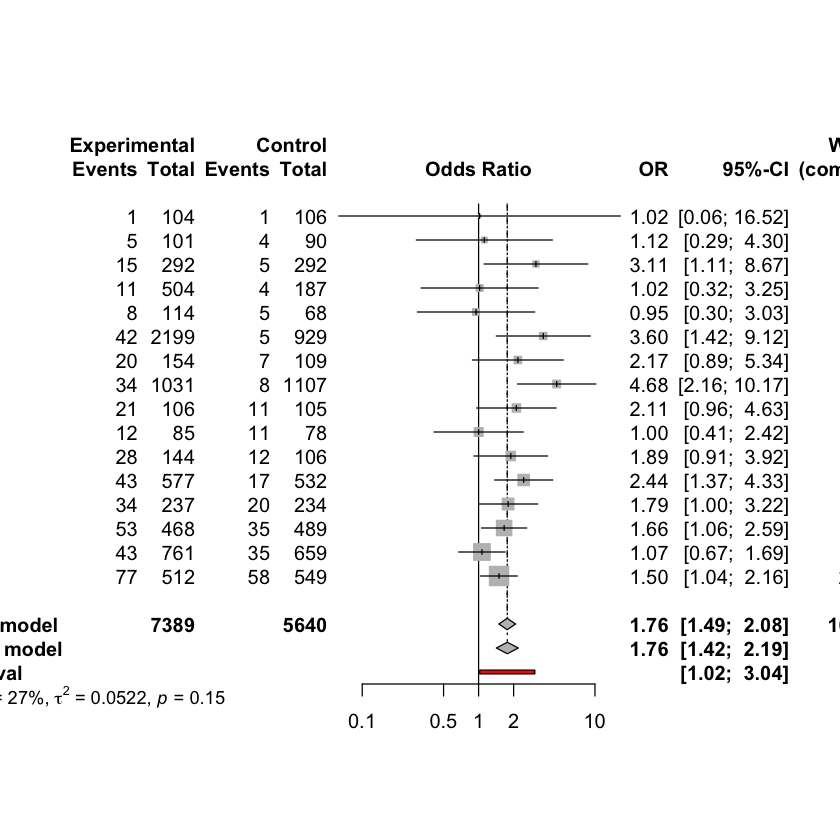

In [69]:
forest(m.publ, prediction = TRUE)

In [27]:
paste(data$'name', ', ', data$'year')

[1] "Slama ,  1990"    "Porter ,  1972"   "Demers ,  1990"   "Stewart ,  1982" 
 [5] "Page ,  1986"     "Slama ,  1995"    "Haug ,  1994"     "Russell ,  1979" 
 [9] "Wilson ,  1982"   "McDowell ,  1985" "Janz ,  1987"     "Wilson ,  1990"  
[13] "Vetter ,  1990"   "Higashi ,  1995"  "Russell ,  1983"  "Jamrozik ,  1984"

In [30]:
bcgdata <- read_dta('bcgtrial.dta')
bcgdata

trial,trialnam,authors,startyr,latitude,alloc,tcases,tnoncases,ccases,cnoncases,ttotal,ctotal
<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl+lbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2,Canada,Ferguson & Simes,1933,55,0,6,300,29,274,306,303
1,Northern USA,Aronson,1935,52,0,4,119,11,128,123,139
8,Chicago,Rosenthal et al,1941,42,1,17,1699,65,1600,1716,1665
10,Georgia (Sch),Comstock & Webster,1947,33,1,5,2493,3,2338,2498,2341
9,Puerto Rico,Comstock et al,1949,18,1,186,50448,141,27197,50634,27338
11,Georgia (Comm),Comstock et al.,1950,33,1,27,16886,29,17825,16913,17854
4,Madanapalle,Frimont-Moller et al,1950,13,1,33,5036,47,5761,5069,5808
3,UK,Hart & Sutherland,1950,53,0,62,13536,248,12619,13598,12867
7,South Africa,Coetzee & Berjak,1965,27,0,29,7470,45,7232,7499,7277


In [32]:
bcgdata.publ = metabin(bcgdata$'tcases', 
                 bcgdata$'ttotal',
                 bcgdata$'ccases',
                 bcgdata$'ctotal',
                 sm="OR" #, label.left = paste(data$'name', ', ', data$'year')
                        )

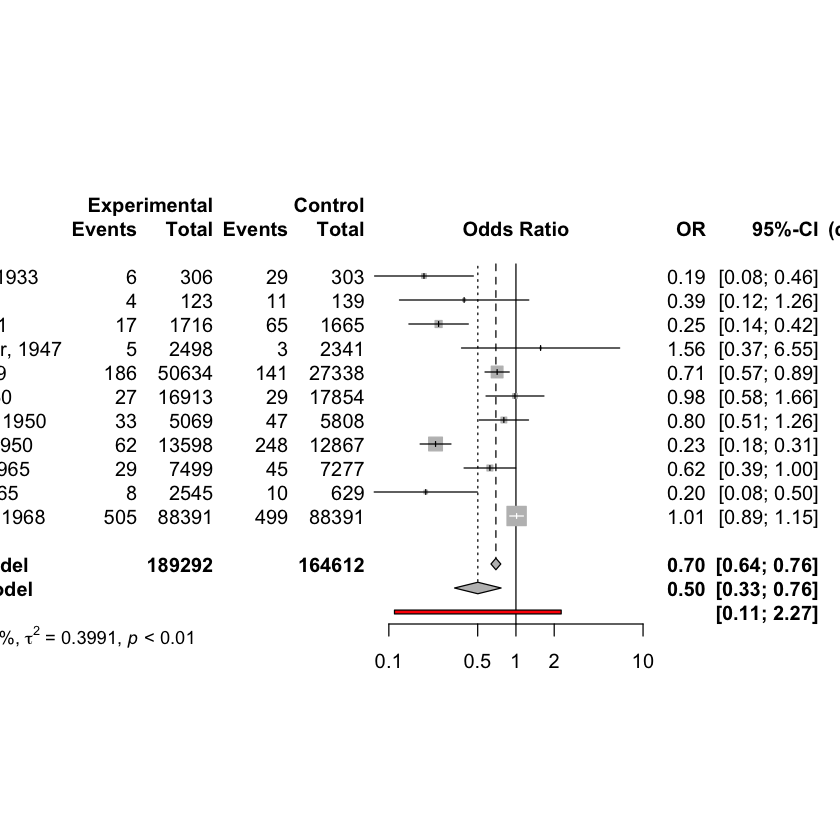

In [68]:
forest(bcgdata.publ, prediction = TRUE)

In [42]:
bcgdata.publ = metabin(tcases, 
                 ttotal,
                 ccases,
                 ctotal,
                 sm="OR",
                 data = bcgdata, 
                 studlab = paste0(authors, ', ', startyr),
                 method.tau = "PM"
                        )
bcgdata.publ

Number of studies combined: k = 11
Number of observations: o = 353904
Number of events: e = 2009

                         OR           95%-CI     z  p-value
Common effect model  0.6955 [0.6363; 0.7601] -8.01 < 0.0001
Random effects model 0.5013 [0.3287; 0.7645] -3.21   0.0013

Quantifying heterogeneity:
 tau^2 = 0.3991 [0.1446; 1.5368]; tau = 0.6318 [0.3803; 1.2397]
 I^2 = 92.1% [87.9%; 94.9%]; H = 3.56 [2.87; 4.42]

Test of heterogeneity:
      Q d.f.  p-value
 126.98   10 < 0.0001

Details on meta-analytical method:
- Mantel-Haenszel method
- Paule-Mandel estimator for tau^2
- Q-Profile method for confidence interval of tau^2 and tau

In [65]:
pdf("forest-m1.pdf", width = 12, height = 5)
forest(bcgdata.publ,
       label.left = "Favours placebo" , 
       label.right = "Favours treatment")
dev.off()

pdf 
  2

In [67]:
pdf("forest-m2.pdf", width = 12, height = 5)
forest(bcgdata.publ,
       label.left = "Favours placebo" , 
       label.right = "Favours treatment",
       prediction = TRUE)
dev.off()

pdf 
  2

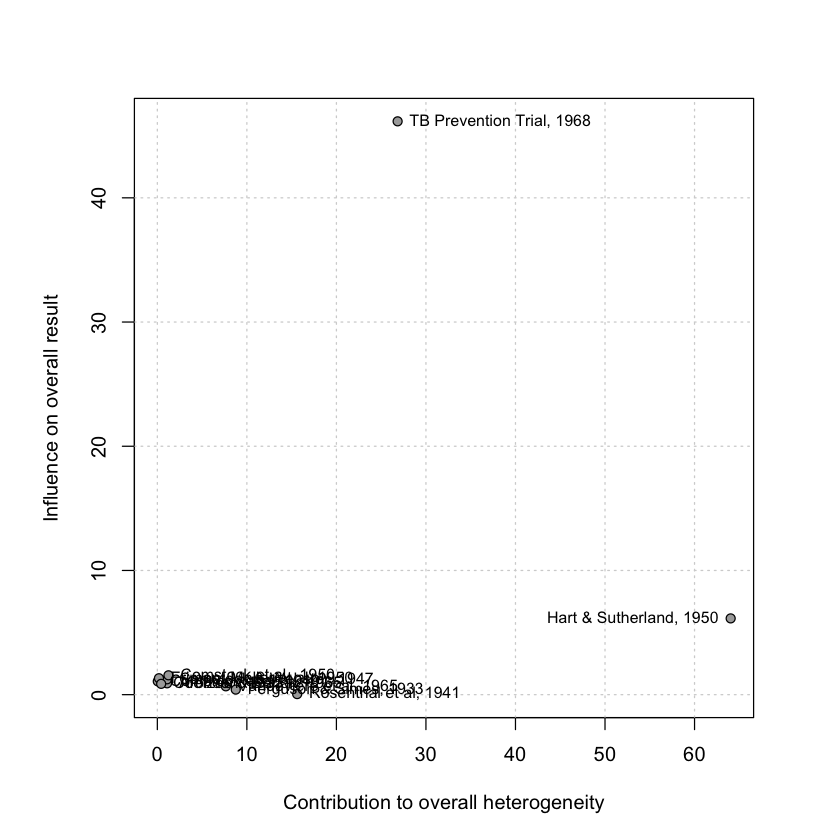

In [70]:
baujat(bcgdata.publ)

[1] 126.9752

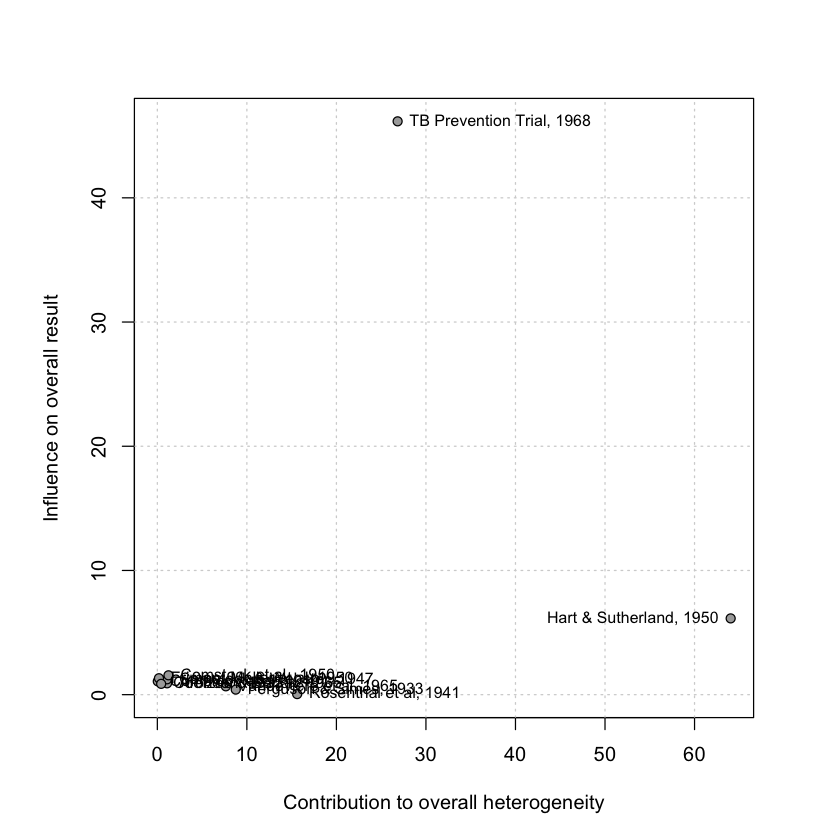

In [71]:
sum(baujat(bcgdata.publ)$x)

In [82]:
bcgdata

trial,trialnam,authors,startyr,latitude,alloc,tcases,tnoncases,ccases,cnoncases,ttotal,ctotal
<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl+lbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2,Canada,Ferguson & Simes,1933,55,0,6,300,29,274,306,303
1,Northern USA,Aronson,1935,52,0,4,119,11,128,123,139
8,Chicago,Rosenthal et al,1941,42,1,17,1699,65,1600,1716,1665
10,Georgia (Sch),Comstock & Webster,1947,33,1,5,2493,3,2338,2498,2341
9,Puerto Rico,Comstock et al,1949,18,1,186,50448,141,27197,50634,27338
11,Georgia (Comm),Comstock et al.,1950,33,1,27,16886,29,17825,16913,17854
4,Madanapalle,Frimont-Moller et al,1950,13,1,33,5036,47,5761,5069,5808
3,UK,Hart & Sutherland,1950,53,0,62,13536,248,12619,13598,12867
7,South Africa,Coetzee & Berjak,1965,27,0,29,7470,45,7232,7499,7277


Number of studies combined: k = 6
Number of observations: o = 222068
Number of events: e = 1456

                         OR           95%-CI     z  p-value
Common effect model  0.7084 [0.6383; 0.7863] -6.48 < 0.0001
Random effects model 0.3858 [0.2171; 0.6855] -3.25   0.0012

Quantifying heterogeneity:
 tau^2 = 0.3991 [0.1250; 2.7538]; tau = 0.6318 [0.3536; 1.6594]
 I^2 = 95.4% [92.3%; 97.2%]; H = 4.66 [3.60; 6.03]

Test of heterogeneity:
      Q d.f.  p-value
 108.55    5 < 0.0001

Details on meta-analytical method:
- Mantel-Haenszel method
- Paule-Mandel estimator for tau^2
- Q-Profile method for confidence interval of tau^2 and tau

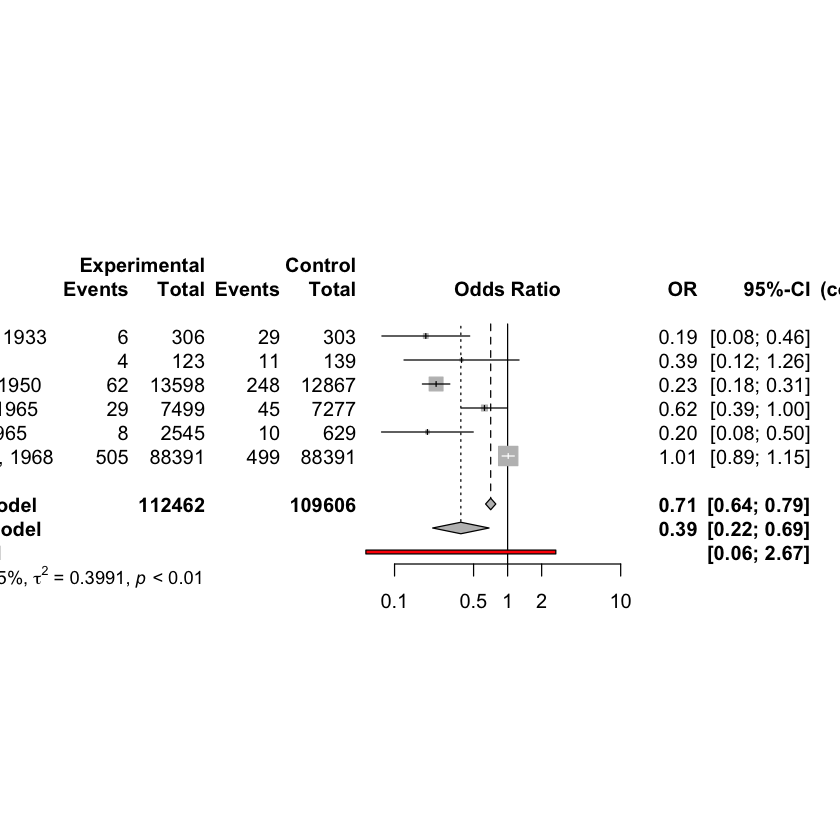

In [84]:
bcgdata.alloc.publ = metabin(tcases, 
                 ttotal,
                 ccases,
                 ctotal,
                 sm="OR",
                 data = bcgdata[bcgdata$alloc == 0, ], 
                 studlab = paste0(authors, ', ', startyr),
                 method.tau = "PM"
                        )
bcgdata.alloc.publ
forest(bcgdata.alloc.publ, prediction = TRUE)

Number of studies combined: k = 5
Number of observations: o = 131836
Number of events: e = 553

                         OR           95%-CI     z  p-value
Common effect model  0.6613 [0.5580; 0.7838] -4.77 < 0.0001
Random effects model 0.6748 [0.3876; 1.1748] -1.39   0.1644

Quantifying heterogeneity:
 tau^2 = 0.3029 [0.0457; 3.6286]; tau = 0.5503 [0.2138; 1.9049]
 I^2 = 77.2% [44.9%; 90.6%]; H = 2.10 [1.35; 3.26]

Test of heterogeneity:
     Q d.f. p-value
 17.56    4  0.0015

Details on meta-analytical method:
- Mantel-Haenszel method
- Paule-Mandel estimator for tau^2
- Q-Profile method for confidence interval of tau^2 and tau

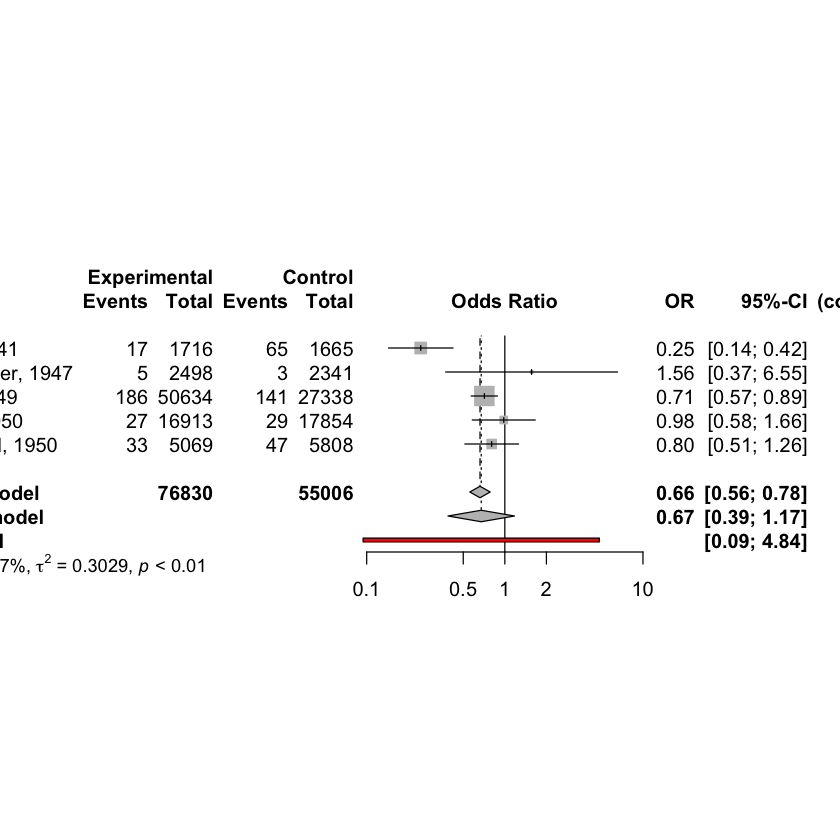

In [83]:
bcgdata.alloc.publ = metabin(tcases, 
                 ttotal,
                 ccases,
                 ctotal,
                 sm="OR",
                 data = bcgdata[bcgdata$alloc == 1, ], 
                 studlab = paste0(authors, ', ', startyr),
                 method.tau = "PM"
                        )
bcgdata.alloc.publ
forest(bcgdata.alloc.publ, prediction = TRUE)